In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)

In [2]:
df_combined_path = "../../../data/France/processed_data/combined_df.csv"
df_weather = "../../../data/France/processed_data/weather_till_march2.csv"

df = pd.read_csv(df_combined_path, low_memory=False)
df_weatehr = pd.read_csv(df_weather, low_memory=False)

In [3]:
df.rename(
    columns={
        "data_type": "data_type",
        "source": "provider",
        "Sales Date": "date",
        "Outlet SF ID": "customer_code",
        "Store Participant Code": "customer_name",
        "SKU SF ID": "sku_code",
        "SKU Name": "sku_name",
        "Brand Variant": "brand_variant",
        "Brand Family": "brand_name",
        "Category": "category",
        "Volume in Unit": "sales_amount",
        "Volume in Packs": "sales_quantity",
        "Ownership Type": "channel_name",
        "Latitude": "latitude",
        "Longitude": "longitude",
        "Territory Id": "route",
        # Extra
        "Brand": "brand",
        "SKU Clean": "sku_clean",
        "Month": "month",
    },
    inplace=True,
)

df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [4]:
print(df.shape)

(1051767, 18)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1051767 entries, 0 to 1051766
Data columns (total 18 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   data_type       1051767 non-null  object        
 1   provider        1051767 non-null  object        
 2   date            1051767 non-null  datetime64[ns]
 3   customer_code   1051767 non-null  object        
 4   customer_name   1051184 non-null  float64       
 5   sku_code        1051767 non-null  object        
 6   sku_name        889979 non-null   object        
 7   brand_variant   889979 non-null   object        
 8   brand_name      889979 non-null   object        
 9   category        852171 non-null   object        
 10  sales_amount    1051767 non-null  int64         
 11  sales_quantity  1051767 non-null  float64       
 12  channel_name    1049146 non-null  object        
 13  latitude        1051184 non-null  float64       
 14  longitude       10

In [6]:
df_sellin = df[df["data_type"] == "sell_in"].copy()
df_sellout = df[df["data_type"] == "sell_out"].copy()

## Check for 99999 in Sell Out

In [8]:
total_rows = len(df_sellout)
count_99999 = (df_sellout["sku_code"] == "0").sum()

percentage = (count_99999 / total_rows) * 100

print(f"99999 appears in {percentage:.2f}% of total rows")

99999 appears in 14.32% of total rows


In [9]:
result = (
    df_sellout.assign(is_99999=df_sellout["sku_code"] == "0")
    .groupby("provider")["is_99999"]
    .mean()
    * 100
)

print(result)

provider
Bimedia    14.313318
Devlyx     24.150349
Logista    14.190860
Name: is_99999, dtype: float64


In [10]:
# Total unique shops
total_shops = df_sellout["customer_name"].nunique()

# Shops where 99999 appears at least once
shops_with_99999 = df_sellout.loc[
    df_sellout["sku_code"] == "0", "customer_name"
].nunique()

# Percentage
percentage = (shops_with_99999 / total_shops) * 100

print(f"{percentage:.2f}% shops have sku_code 99999")

100.00% shops have sku_code 99999


In [11]:
total_shops

603

In [12]:
summary = (
    df_sellout.assign(is_99999=df_sellout["sku_code"] == "0")
    .groupby(["provider", "customer_name"])["is_99999"]
    .max()  # shop level (at least once)
    .reset_index()
    .groupby("provider")["is_99999"]
    .mean()
    * 100
)

print(summary)

provider
Bimedia    100.0
Devlyx     100.0
Logista    100.0
Name: is_99999, dtype: float64


## Check Weather Corelation with Sell Out

In [13]:
df_weatehr["date"] = pd.to_datetime(df_weatehr["date"], format="%Y-%m-%d")

In [14]:
df_sellout_with_weather = pd.merge(
    df_sellout, df_weatehr, how="left", on=["date", "latitude", "longitude"]
)

In [15]:
# Check for if it is rain.
df_sellout_with_weather["is_rain"] = df_sellout_with_weather["precipitation"] > 0
df_sellout_with_weather.head()

,data_type,provider,date,customer_code,customer_name,sku_code,sku_name,brand_variant,brand_name,category,sales_amount,sales_quantity,channel_name,latitude,longitude,route,brand,month,temperature,precipitation,weathercode,windspeed,is_rain
0,sell_out,Bimedia,2026-02-01,0011t000011b5rcAAA,576579.0,a0UJz000007USXVMA4,VUSE GORL PN950 MK 10 AQ 1 FRA,FR_BV_,FR_BF_,Vapour Devices,1,1.0,Independent,48.86806,2.35239,a0D1t000005iLAGEA2,NaN,2026-02,6.7,2.9,53.0,13.9,True
1,sell_out,Bimedia,2026-02-01,0011t000011b5rcAAA,576579.0,a0UJz000009CfTdMAK,VUSE POD2 CARTG 2/10 BK 10 FRA V3,FR_BV_,FR_BF_,Vapour Liquids,1,1.0,Independent,48.86806,2.35239,a0D1t000005iLAGEA2,NaN,2026-02,6.7,2.9,53.0,13.9,True
2,sell_out,Bimedia,2026-02-01,0011t000011b5rcAAA,576579.0,a0UJz000009CfrpMAC,VUSE POD2 CARTG 2/10 MK 10 FRA,FR_BV_,FR_BF_,Vapour Liquids,1,1.0,Independent,48.86806,2.35239,a0D1t000005iLAGEA2,NaN,2026-02,6.7,2.9,53.0,13.9,True
3,sell_out,Bimedia,2026-02-01,0011t000011bCLOAA2,307057.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,80,4.0,COCO,48.89021,2.32111,a0D1t000005iLAnEAM,VELO,2026-02,6.7,2.9,53.0,13.9,True
4,sell_out,Bimedia,2026-02-01,0011t000011bCLOAA2,307057.0,a0UJz00000C50QHMAZ,87635 - VELO ICE ALASKA 17MG,FR_BV_87635 - VELO ICE ALASKA 17MG,FR_BF_VELO,Oral,1,1.0,COCO,48.89021,2.32111,a0D1t000005iLAnEAM,VELO,2026-02,6.7,2.9,53.0,13.9,True


In [16]:
df_specific_customer_data = df_sellout_with_weather[
    df_sellout_with_weather["customer_name"] == 576579.0
].copy()

In [17]:
corr = df_sellout_with_weather["sales_quantity"].corr(
    df_specific_customer_data["precipitation"]
)
print(f"Correlation: {corr:.4f}")

Correlation: 0.0103


## SELL OUT DATA

In [7]:
df_sellout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 929460 entries, 122307 to 1051766
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   data_type       929460 non-null  object        
 1   provider        929460 non-null  object        
 2   date            929460 non-null  datetime64[ns]
 3   customer_code   929460 non-null  object        
 4   customer_name   712861 non-null  float64       
 5   sku_code        929460 non-null  object        
 6   sku_name        790922 non-null  object        
 7   brand_variant   790922 non-null  object        
 8   brand_name      790922 non-null  object        
 9   category        760326 non-null  object        
 10  sales_amount    929460 non-null  int64         
 11  sales_quantity  929460 non-null  float64       
 12  channel_name    711529 non-null  object        
 13  latitude        712861 non-null  float64       
 14  longitude       712861 non-null  fl

In [8]:
total_transactions_so = len(df_sellout)
total_transactions_si = len(df_sellin)

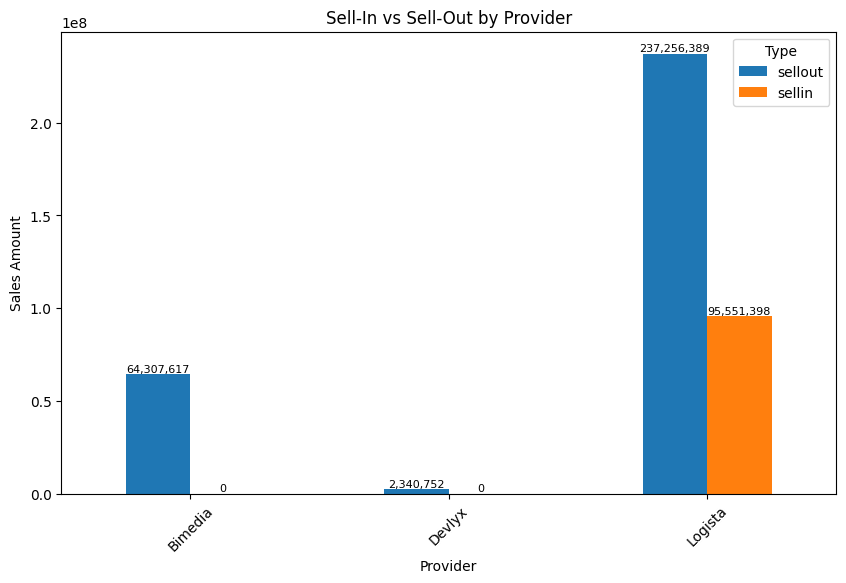

In [9]:
sellout = df_sellout.groupby("provider")["sales_amount"].sum()
sellin = df_sellin.groupby("provider")["sales_amount"].sum()

df_compare = pd.concat([sellout, sellin], axis=1).rename(
    columns={"sales_amount": "sellout"}
)

df_compare.columns = ["sellout", "sellin"]
df_compare = df_compare.fillna(0)

ax = df_compare.plot(kind="bar", figsize=(10, 6))

# Add labels on bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.title("Sell-In vs Sell-Out by Provider")
plt.xlabel("Provider")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.legend(title="Type")
plt.show()

In [ ]:
def plot_with_stock_remaining(df_sellin, df_sellout, customer_code, sku_code):

    df_sellin = df_sellin[df_sellin["customer_code"] == customer_code].copy()
    df_sellout_logista = df_sellout[df_sellout["customer_code"] == customer_code].copy()

    temp = df_sellout_logista[df_sellout_logista["sku_code"] == sku_code][
        ["date", "sales_quantity"]
    ]

    temp2 = df_sellin[df_sellin["sku_code"] == sku_code][
        ["date", "sales_quantity"]
    ].rename(columns={"sales_quantity": "sales_quantity_sellin"})

    temp = temp.groupby("date")["sales_quantity"].sum()
    temp2 = temp2.groupby("date")["sales_quantity_sellin"].sum()

    final_temp = pd.merge(temp, temp2, on="date", how="outer")
    final_temp.fillna(0, inplace=True)

    final_temp["so_stock_remaining"] = (
        final_temp["sales_quantity_sellin"] - final_temp["sales_quantity"]
    ).cumsum()

    final_temp = final_temp.sort_index().reset_index()

    x = final_temp["date"]

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=x, y=final_temp["sales_quantity_sellin"], name="Sell-in", opacity=0.7
        )
    )
    fig.add_trace(
        go.Scatter(x=x, y=final_temp["sales_quantity"], name="Sell-out", opacity=0.7)
    )

    fig.add_trace(
        go.Scatter(
            x=x,
            y=final_temp["so_stock_remaining"],
            mode="lines+markers",
            name="Stock Remaining",
            line=dict(color="black", width=2),
        )
    )

    fig.update_layout(
        title="Sell-in vs Sell-out + Stock Remaining",
        xaxis_title="Date",
        yaxis_title="Quantity",
        barmode="group",
        template="plotly_white",
        width=1000,
        height=500,
    )

    fig.show()

In [20]:
plot_with_stock_remaining(
    df_sellin,
    df_sellout,
    customer_code="0011t000011b5TiAAI",
    sku_code="a0U1t000002PXlqEAG",
)

         date  sales_quantity  sales_quantity_sellin  so_stock_remaining
0  2026-01-01            25.0                    0.0               -25.0
1  2026-01-02            24.0                    0.0               -49.0
2  2026-01-03            31.0                    0.0               -80.0
3  2026-01-04            20.0                    0.0              -100.0
4  2026-01-05            20.0                    0.0              -120.0
5  2026-01-06            16.0                    0.0              -136.0
6  2026-01-07            15.0                    0.0              -151.0
7  2026-01-08            17.0                    0.0              -168.0
8  2026-01-09            48.0                    0.0              -216.0
9  2026-01-10            33.0                    0.0              -249.0
10 2026-01-11            29.0                    0.0              -278.0
11 2026-01-12            17.0                    0.0              -295.0
12 2026-01-13            19.0                    0.

### Plot daily, weekly, and Monthly SO and SE

In [12]:
customer_code = "0011t000011b5TiAAI"
sku_code = "a0U1t000002PXlqEAG"
temp = df_sellout.query("customer_code == @customer_code and sku_code == @sku_code")
temp = temp.sort_values("date").set_index("date")

In [13]:
def plot_summary(sellin, sellout, customer_code, sku_code):

    plot_with_stock_remaining(sellin, sellout, customer_code, sku_code)

    # -----------------------
    # Filter data
    # -----------------------
    si = sellin[
        (sellin["customer_code"] == customer_code) & (sellin["sku_code"] == sku_code)
    ].copy()

    so = sellout[
        (sellout["customer_code"] == customer_code) & (sellout["sku_code"] == sku_code)
    ].copy()

    # -----------------------
    # Prepare datetime index
    # -----------------------
    si["date"] = pd.to_datetime(si["date"])
    so["date"] = pd.to_datetime(so["date"])

    si = si.sort_values("date").set_index("date")
    so = so.sort_values("date").set_index("date")

    # =======================
    # DAILY (Line)
    # =======================
    # daily_si = si["sales_quantity"].resample("D").sum()
    # daily_so = so["sales_quantity"].resample("D").sum()

    # fig_daily = go.Figure()
    # fig_daily.add_trace(
    #     go.Scatter(x=daily_si.index, y=daily_si.values, mode="lines", name="Sell-in")
    # )
    # fig_daily.add_trace(
    #     go.Scatter(x=daily_so.index, y=daily_so.values, mode="lines", name="Sell-out")
    # )

    # fig_daily.update_layout(
    #     title="Daily Sell-in vs Sell-out",
    #     xaxis_title="Date",
    #     yaxis_title="Quantity",
    #     template="plotly_white",
    # )

    # fig_daily.show()

    # =======================
    # WEEKLY (Bar)
    # =======================
    weekly_si = si["sales_quantity"].resample("W").sum()
    weekly_so = so["sales_quantity"].resample("W").sum()

    fig_weekly = go.Figure()
    fig_weekly.add_trace(go.Bar(x=weekly_si.index, y=weekly_si.values, name="Sell-in"))
    fig_weekly.add_trace(go.Bar(x=weekly_so.index, y=weekly_so.values, name="Sell-out"))

    fig_weekly.update_layout(
        title="Weekly Sell-in vs Sell-out",
        xaxis_title="Week",
        yaxis_title="Quantity",
        barmode="group",
        template="plotly_white",
    )

    fig_weekly.show()

    # =======================
    # MONTHLY (Bar with month names)
    # =======================
    monthly_si = si["sales_quantity"].resample("ME").sum()
    monthly_so = so["sales_quantity"].resample("ME").sum()

    monthly_labels = monthly_si.index.strftime("%b-%Y")

    fig_monthly = go.Figure()
    fig_monthly.add_trace(go.Bar(x=monthly_labels, y=monthly_si.values, name="Sell-in"))
    fig_monthly.add_trace(
        go.Bar(x=monthly_labels, y=monthly_so.values, name="Sell-out")
    )

    fig_monthly.update_layout(
        title="Monthly Sell-in vs Sell-out",
        xaxis_title="Month",
        yaxis_title="Quantity",
        barmode="group",
        template="plotly_white",
    )

    fig_monthly.show()

In [14]:
plot_summary(df_sellin, df_sellout, customer_code, sku_code)

In [15]:
df_sellin.head()

,data_type,provider,date,customer_code,customer_name,sku_code,sku_name,brand_variant,brand_name,category,sales_amount,sales_quantity,channel_name,latitude,longitude,route
0,sell_in,Logista,2026-01-05,0011t000011b5fiAAA,300003.0,a0U3W000002A7QeUAK,86195 - VELO ICE COOL 10MG,FR_BV_86195 - VELO ICE COOL 10MG,FR_BF_VELO,Oral,5,5.0,COCO,48.87946,2.32691,a0D1t000005iLAnEAM
1,sell_in,Logista,2026-01-05,0011t000011b5fiAAA,300003.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,15,15.0,COCO,48.87946,2.32691,a0D1t000005iLAnEAM
2,sell_in,Logista,2026-01-05,0011t000011b5fiAAA,300003.0,a0UJz000005H9AVMA0,87571 - VELO ICE ALASKA 14MG,FR_BV_87571 - VELO ICE ALASKA 14MG,FR_BF_VELO,Oral,10,10.0,COCO,48.87946,2.32691,a0D1t000005iLAnEAM
3,sell_in,Logista,2026-01-05,0011t000011b5fiAAA,300003.0,a0UJz000009Ce1KMAS,VUSE POD2 CARTG 2/10 MJ 10 FRA M3,FR_BV_,FR_BF_,Vapour Liquids,5,5.0,COCO,48.87946,2.32691,a0D1t000005iLAnEAM
4,sell_in,Logista,2026-01-05,0011t000011b5fiAAA,300003.0,a0UJz000009CevlMAC,VUSE POD2 CARTG 2/10 PD 10 FRA NEW,FR_BV_,FR_BF_,Vapour Devices,5,6.0,COCO,48.87946,2.32691,a0D1t000005iLAnEAM
